# Equació de Duffing amb soroll

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from typing import Tuple
import numpy.typing as npt

Algorisme de l'article de Strahan et al. 2023 (pàgina 3),
a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs, on $f(t)=sin(t)$.
$$x'=y + \epsilon f(t)$$ $$y'=x-x^3$$


In [20]:
def edo_duffing_soroll(t, z, epsilon=0.05, funcio_soroll=np.sin):
    """Paràmetres:
        t: temps
        z: posició al pla R^2
        epsilon: paràmetre entre 0 i 1 que regula el soroll
        funcio_soroll: pertorbació que depèn del temps
    Retorna el camp vectorial del sistema d'EDOs autònom x'=y; y'=x-x^3.
    """
    x, y = z
    soroll = epsilon * funcio_soroll(t)
    camp_vectorial = [y + soroll, x - x**3]
    return np.array(camp_vectorial)

Paràmetres

In [45]:
t_span = [0, 50]
t_steps = 1000
t_valors = np.linspace(t_span[0], t_span[1], t_steps)
condicions_inicials = [[0.3, 0.3]]

radi = 0.3
centre_esquerre = (-1, 0)
centre_dret = (1, 0)
resolucio_grafica = 2000

In [9]:
def pertany_a_circumferencia(x: float,
                             y: float, 
                             centre: Tuple[float, float], 
                             radi: float
                             ) -> bool:
    a, b = centre
    return (x-a)**2 + (y-b)**2 <= radi**2

In [ ]:
def pertany_a_la_regio_A(x: float, y: float) -> bool:
    return pertany_a_circumferencia(x, y, centre_esquerre, radi) \
        or pertany_a_circumferencia(x, y, centre_dret, radi)

In [35]:
def grafica_circumferencia(centre: Tuple[float, float],
                           radi: float, 
                           nom_regio:str,
                           resolucio: int = resolucio_grafica):
    theta = np.linspace(0, 2*np.pi, resolucio)
    a, b = centre
    xx = radi*np.cos(theta) + a
    yy = radi*np.sin(theta)
    plt.plot(xx, yy + b, 'black')
    plt.plot(xx, - yy + b, 'black')
    plt.annotate(nom_regio, centre)

def grafica_regio_A():
    nom_regio='A'
    grafica_circumferencia(centre_esquerre, radi, nom_regio)
    grafica_circumferencia(centre_dret, radi, nom_regio)


In [51]:
def grafica_solucio(edo, t_span, t_valors, condicions_inicials, desa_pdf=False):
    grafica_regio_A()
    for ci in condicions_inicials:
        sol = solve_ivp(edo, t_span, ci, t_eval=t_valors)
        plt.plot(sol.y[0], sol.y[1], color = 'orange')
        inici_string = f'Inici = ({ci[0]:.2f}, {ci[1]:.2f})'
        plt.plot(ci[0], ci[1], '-o', label = inici_string)
        final = (sol.y[0][-1], sol.y[1][-1]) #Posició final
        final_string = f'Final = ({final[0]:.2f}, {final[1]:.2f})'
        plt.plot(final[0], final[1], '-o', color = 'red', label = final_string)
    plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid()
    plt.gca().set_aspect('equal')
    if desa_pdf:
        plt.savefig('edo.pdf')
    plt.show()

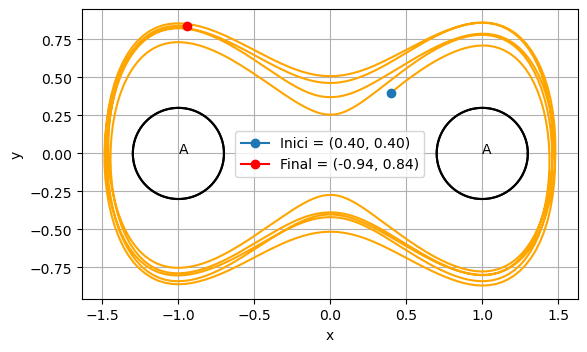

In [52]:
grafica_solucio(edo_duffing_soroll, t_span, t_valors, condicions_inicials=[[0.4, 0.4]])

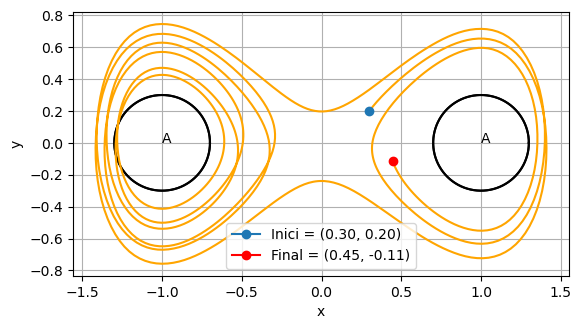

In [53]:
grafica_solucio(edo_duffing_soroll, t_span, t_valors, condicions_inicials=[[0.3, 0.2]])

### 1. Generar $n$ posicions inicials aleatòries

In [16]:
x_min, x_max = (-2, 2)
y_min, y_max = (-1.5, 1.5)

In [26]:
def generar_condicions_inicials(num_ci: int) -> list[float]:
    """num_ci = nombre de condicions inicials"""
    condicions_inicials = []
    for _ in range(num_ci):
        x0 = np.random.uniform(x_min, x_max)
        y0 = np.random.uniform(y_min, y_max)
        while pertany_a_la_regio_A(x0, y0):
            x0 = np.random.uniform(x_min, x_max)
            y0 = np.random.uniform(y_min, y_max)
        ci = [x0,y0]
        condicions_inicials.append(ci)
    return condicions_inicials

condicions_inicials = generar_condicions_inicials(1)

### 2. Generar trajectòries a partir de les posicions inicials

In [33]:
num_trajectories = 4
dimensio = 2

In [27]:
def generar_trajectories(edo, 
                         num_trajectories: int, 
                         condicions_inicials: list,
                         t_valors
                         ):
    """
    Paràmetres:
        edo: funció que representa el camp vectorial d'una EDO
        num_trajectories: nombre de trajectòries a generar
        condicions_inicials: llista que conté condicions inicials [x0,y0]
        t_valors: np.array[float], conté els instants de temps on avaluem l'EDO
        
    """
    trajectories = np.zeros((num_trajectories, len(t_valors), dimensio))
    for i, ci in enumerate(condicions_inicials):
        sol = solve_ivp(edo, t_span, ci, t_eval=t_valors)
        trajectoria = np.vstack([sol.y[0], sol.y[1]])
        trajectoria = trajectoria.T
        # print(f'{trajectoria = }')
        trajectories[i] = trajectoria
    return trajectories

In [31]:
trajectories = generar_trajectories(edo_duffing_soroll,
                                    num_trajectories, 
                                    condicions_inicials,
                                    t_valors)

In [55]:
trajectories.shape

(2, 3, 2)